# Advanced Workflows with nestkit

This notebook covers nestkit's advanced analysis tools. It assumes familiarity with the basics covered in **[01  -  Basic Usage](01_basic_usage.ipynb)**.

## What you'll learn

1. Multi-model statistical comparison with `NestedCVComparator`
2. Feature importance aggregation with `FeatureImportanceAggregator`
3. Hyperparameter stability diagnostics
4. Callbacks: progress, logging, checkpointing

## Prerequisites

```bash
pip install nestkit[full]
```

In [1]:
import logging
import os
import tempfile
import time
import warnings

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from nestkit import NestedCVClassifier
from nestkit.callbacks import CheckpointCallback, LoggingCallback, ProgressCallback
from nestkit.comparison import NestedCVComparator
from nestkit.diagnostics import HyperparameterStability
from nestkit.importance import FeatureImportanceAggregator
from nestkit.plotting import (
    plot_bayesian_posterior,
    plot_comparison,
    plot_critical_difference,
    plot_importance,
    plot_rank_stability_features,
    plot_score_differences,
    plot_selection_frequency,
)

warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## 0. Data Setup

We reuse the same datasets from notebook 01 to maintain continuity. For multi-model comparison we need all models evaluated on **identical outer folds**, so we fix `outer_cv=5`, `inner_cv=3`, and `random_state=42` throughout.

In [2]:
X_clf, y_clf = load_breast_cancer(return_X_y=True)
feature_names_clf = list(load_breast_cancer().feature_names)

X_reg, y_reg = load_diabetes(return_X_y=True)
feature_names_reg = list(load_diabetes().feature_names)

print(f"Classification: {X_clf.shape}, Regression: {X_reg.shape}")

Classification: (569, 30), Regression: (442, 10)


## 1. Multi-Model Statistical Comparison

A common question is: **"Is model A really better than model B?"** Simply comparing mean scores is unreliable because outer-fold scores are correlated (overlapping training sets). `NestedCVComparator` provides three principled approaches:

1. **Nadeau-Bengio corrected paired t-test**  -  frequentist test that corrects for the non-independence of CV folds
2. **Bayesian correlated t-test with ROPE**  -  gives posterior probabilities that model A is better, practically equivalent, or worse
3. **Critical difference diagram**  -  visual ranking of 3+ models (Demsar, 2006)

### 1.1 Fitting multiple models on identical folds

In [3]:
# All models share identical outer_cv, inner_cv, random_state
common = dict(outer_cv=5, inner_cv=3, scoring="roc_auc", random_state=42)

# Model 1: Random Forest
ncv_rf = NestedCVClassifier(
    estimator=RandomForestClassifier(random_state=42),
    param_grid={"n_estimators": [50, 100, 200], "max_depth": [3, 5, 10]},
    **common,
)
ncv_rf.fit(X_clf, y_clf)

# Model 2: Logistic Regression
ncv_lr = NestedCVClassifier(
    estimator=LogisticRegression(max_iter=5000, random_state=42),
    param_grid={"C": [0.01, 0.1, 1.0, 10.0], "penalty": ["l1", "l2"], "solver": ["saga"]},
    **common,
)
ncv_lr.fit(X_clf, y_clf)

# Model 3: Gradient Boosting
ncv_gb = NestedCVClassifier(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid={"n_estimators": [50, 100], "max_depth": [2, 3, 5], "learning_rate": [0.05, 0.1]},
    **common,
)
ncv_gb.fit(X_clf, y_clf)

print("All models fitted.")

All models fitted.


### 1.2 Building the comparator

Register each model's results under a human-readable name. `NestedCVComparator` validates that all models share identical outer-fold indices.

In [4]:
comparator = NestedCVComparator()
comparator.add("Random Forest", ncv_rf.results_)
comparator.add("Logistic Regression", ncv_lr.results_)
comparator.add("Gradient Boosting", ncv_gb.results_)

display(comparator.summary("roc_auc"))

,model,mean,std,median,ci_lower,ci_upper,min,max,iqr
0,Random Forest,0.990150,0.009537,0.991733,0.972387,1.007913,0.976744,0.999008,0.014053
1,Logistic Regression,0.969716,0.011034,0.970899,0.949166,0.990267,0.956436,0.985260,0.011104
2,Gradient Boosting,0.991837,0.006119,0.990829,0.980441,1.003233,0.985450,0.998347,0.011417


In [5]:
# Rank models by mean ROC AUC
display(comparator.rank_models("roc_auc"))

,model,mean,std,median,ci_lower,ci_upper,min,max,iqr,rank
0,Gradient Boosting,0.991837,0.006119,0.990829,0.980441,1.003233,0.985450,0.998347,0.011417,1
1,Random Forest,0.990150,0.009537,0.991733,0.972387,1.007913,0.976744,0.999008,0.014053,2
2,Logistic Regression,0.969716,0.011034,0.970899,0.949166,0.990267,0.956436,0.985260,0.011104,3


### 1.3 Visual comparison

`plot_comparison` draws paired box-and-strip plots with lines connecting the same fold across models  -  making it easy to spot whether one model consistently wins.

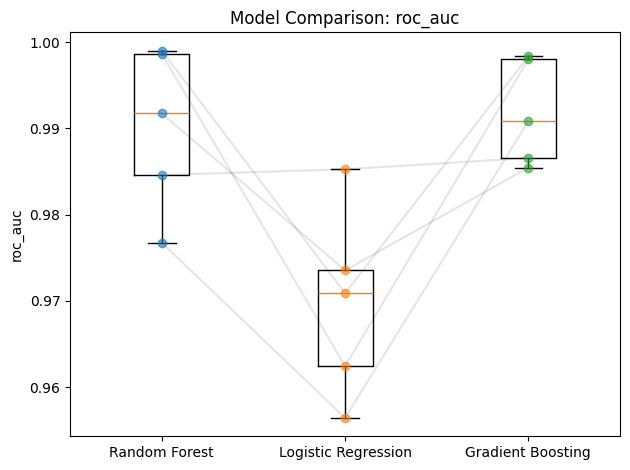

In [6]:
plot_comparison(comparator, "roc_auc", line_alpha=0.1)
plt.tight_layout()

### 1.4 Nadeau-Bengio corrected paired t-test

Standard paired t-tests underestimate the variance of CV scores because training sets overlap. The Nadeau-Bengio correction (2003) adjusts the variance estimate by accounting for the ratio of test-set size to training-set size.

In [7]:
# Single pairwise test
result = comparator.corrected_paired_ttest("roc_auc", "Random Forest", "Logistic Regression")
print("RF vs LR (Nadeau-Bengio corrected):")
for k, v in result.items():
    print(f"  {k}: {v}")

RF vs LR (Nadeau-Bengio corrected):
  t_statistic: 2.212985001740397
  p_value: 0.0913221564679729
  mean_difference: 0.020433280128661656
  corrected_std: 0.009233356806572095
  ci_lower: -0.005202628181490216
  ci_upper: 0.046069188438813524
  n_folds: 5
  significant_at_005: False
  significant_at_001: False


In [8]:
# All pairwise tests with Holm-Bonferroni correction for multiple comparisons
display(comparator.pairwise_corrected_ttest("roc_auc"))

,model_a,model_b,t_statistic,p_value,mean_difference,corrected_std,ci_lower,ci_upper,n_folds,significant_at_005,significant_at_001,p_value_corrected
0,Random Forest,Logistic Regression,2.212985,0.091322,0.020433,0.009233,-0.005203,0.046069,5,False,False,0.273966
1,Random Forest,Gradient Boosting,-0.332813,0.755988,-0.001687,0.005069,-0.015760,0.012386,5,False,False,0.755988
2,Logistic Regression,Gradient Boosting,-2.202411,0.092404,-0.022120,0.010044,-0.050006,0.005765,5,False,False,0.273966


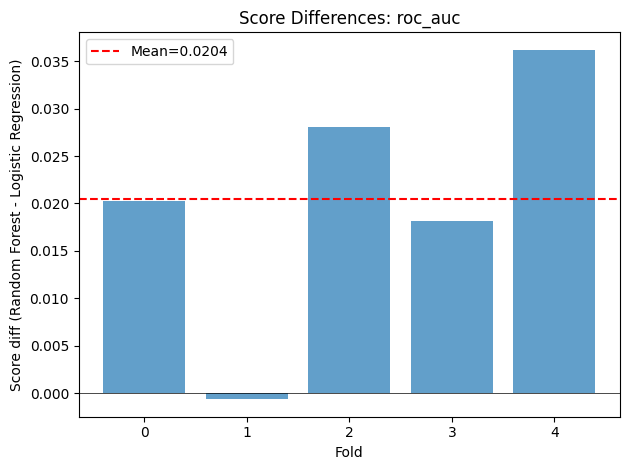

In [9]:
plot_score_differences(comparator, "roc_auc", "Random Forest", "Logistic Regression")
plt.tight_layout()

### 1.5 Bayesian correlated t-test with ROPE

The Bayesian test (Benavoli et al., 2017) partitions the posterior probability mass into three regions:
- **P(A better)**  -  model A's mean score exceeds model B's by more than the ROPE
- **P(equivalent)**  -  the difference lies within the Region of Practical Equivalence
- **P(B better)**  -  model B's mean score exceeds model A's by more than the ROPE

This avoids the binary "significant / not significant" dichotomy and quantifies practical equivalence.

In [10]:
bayes = comparator.bayesian_comparison("roc_auc", "Random Forest", "Gradient Boosting", rope=0.01)
print("Bayesian comparison (RF vs GB):")
for k, v in bayes.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Bayesian comparison (RF vs GB):
  p_a_better: 0.0412
  p_equivalent: 0.8706
  p_b_better: 0.0882
  rope: 0.0100
  mean_difference: -0.0017
  hdi_lower: -0.0158
  hdi_upper: 0.0124


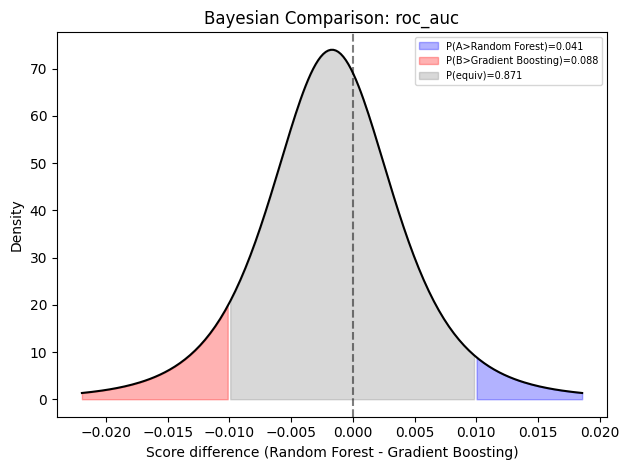

In [11]:
plot_bayesian_posterior(comparator, "roc_auc", "Random Forest", "Gradient Boosting", rope=0.01)
plt.tight_layout()

### 1.6 Critical difference diagram

When comparing three or more models, a critical difference diagram (Demsar, 2006) ranks models by their average rank across folds and groups models that are not significantly different.

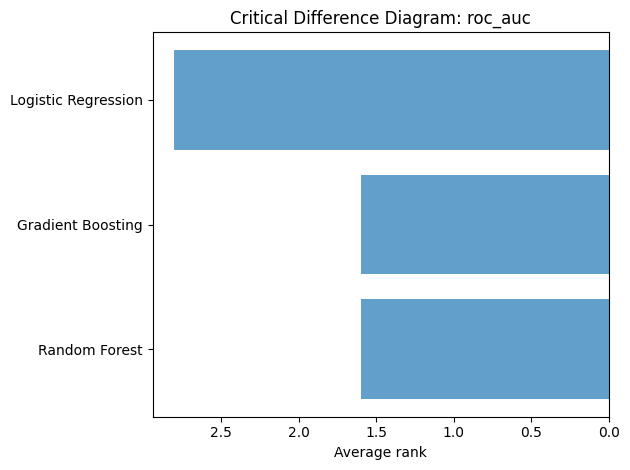

In [12]:
plot_critical_difference(comparator, "roc_auc")
plt.tight_layout()

## 2. Feature Importance Analysis

Feature importances from a single train/test split can be noisy and misleading. `FeatureImportanceAggregator` extracts importances from each outer-fold estimator, aggregates them, and assesses their **stability**  -  how consistently the same features are ranked important across folds.

Key outputs:
- **Summary table**  -  mean, std, CV, and rank statistics per feature
- **Nogueira stability index**  -  measures agreement of top-k feature sets across folds (1 = perfect, 0 = random)
- **Consensus features**  -  features that reliably appear in the top-k across folds

In [13]:
agg = FeatureImportanceAggregator(
    ncv_rf.results_,
    method="model",
    feature_names=feature_names_clf,
)
agg.compute()

print("Top 10 features by mean importance:")
display(agg.summary_.head(10))

Top 10 features by mean importance:


,feature,mean_importance,std_importance,median_importance,min_importance,max_importance,cv_importance,mean_rank,std_rank
0,worst area,0.146445,0.032512,0.154264,0.092618,0.180883,0.222011,1.6,1.341641
1,worst concave points,0.128764,0.008015,0.126759,0.120410,0.141930,0.062244,2.2,0.836660
2,worst perimeter,0.104169,0.030896,0.094333,0.076230,0.148497,0.296590,3.6,1.816590
3,mean concave points,0.095041,0.012074,0.093302,0.080057,0.113452,0.127036,3.4,0.894427
4,worst radius,0.074889,0.008408,0.079846,0.061508,0.080985,0.112277,4.8,1.303840
5,mean concavity,0.066027,0.008330,0.063741,0.057992,0.079635,0.126155,6.4,0.894427
6,mean perimeter,0.062685,0.016754,0.070298,0.043445,0.078647,0.267271,7.0,1.581139
7,mean area,0.048882,0.012535,0.048680,0.030149,0.064769,0.256436,8.8,1.303840
8,mean radius,0.041921,0.006607,0.043092,0.032296,0.049127,0.157613,9.4,1.816590
9,worst concavity,0.040636,0.013206,0.034822,0.029775,0.062906,0.324974,9.4,2.509980


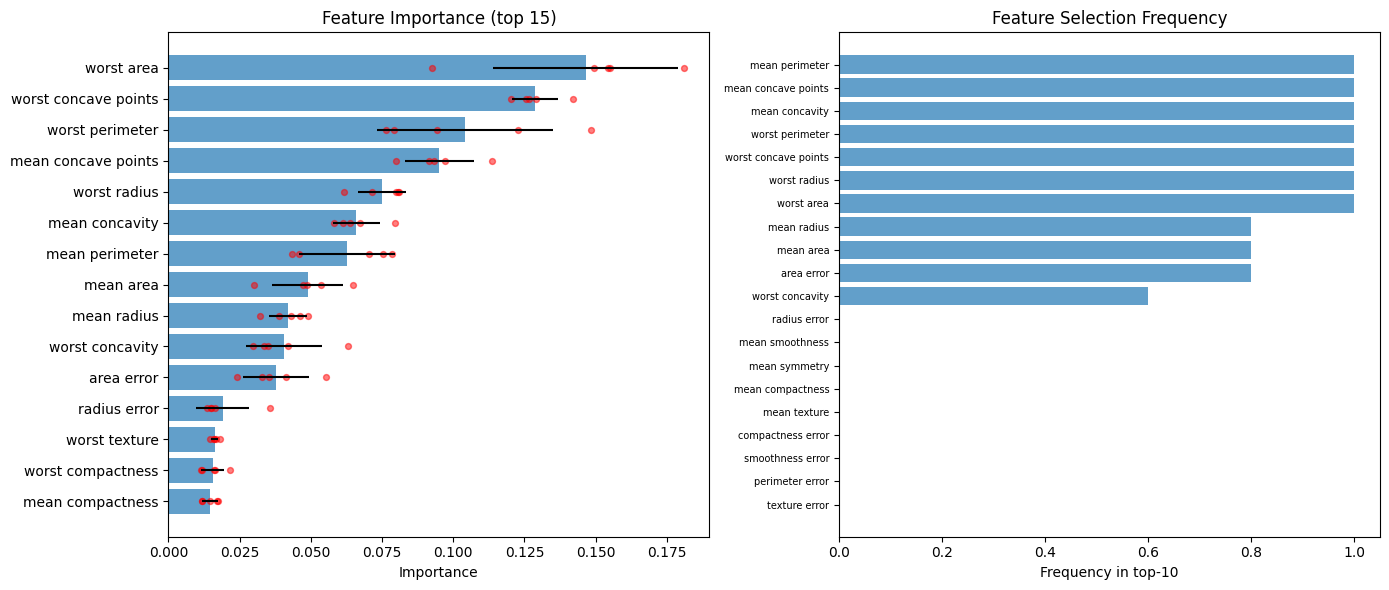

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_importance(agg, top_k=15, ax=axes[0])
plot_selection_frequency(agg, top_k=10, ax=axes[1])
plt.tight_layout()

### 2.1 Nogueira stability index

The Nogueira et al. (2018) stability index measures how consistently the same features appear in the top-k set across folds, corrected for chance agreement. Values near 1 indicate high stability; values near 0 indicate that top features vary across folds.

In [15]:
for k in [5, 10, 15]:
    idx = agg.stability_index(top_k=k)
    print(f"Stability index (top-{k}): {idx:.4f}")

Stability index (top-5): 0.7360
Stability index (top-10): 0.8650
Stability index (top-15): 0.7867


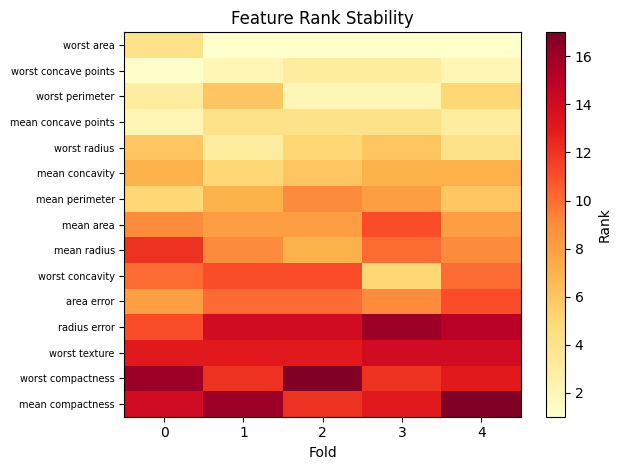

In [16]:
plot_rank_stability_features(agg, top_k=15)
plt.tight_layout()

### 2.2 Consensus features

Two strategies for identifying reliably important features:
- `"top_k"`  -  the top-k features by mean importance
- `"frequency"`  -  features appearing in the top-k in at least a given fraction of folds (more conservative)

In [17]:
# Top-10 by mean importance
top10 = agg.consensus_features(criterion="top_k", top_k=10)
print(f"Top-10 by mean importance:\n  {top10}\n")

# Features in top-10 in at least 80% of folds
consensus = agg.consensus_features(criterion="frequency", top_k=10, min_frequency=0.8)
print(f"Consensus features (top-10, >=80% folds):\n  {consensus}")

Top-10 by mean importance:
  [np.str_('worst area'), np.str_('worst concave points'), np.str_('worst perimeter'), np.str_('mean concave points'), np.str_('worst radius'), np.str_('mean concavity'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean radius'), np.str_('worst concavity')]

Consensus features (top-10, >=80% folds):
  [np.str_('mean radius'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('area error'), np.str_('worst radius'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst concave points')]


In [18]:
# Pairwise Spearman rank correlation between folds
print("Pairwise Spearman rank correlation:")
display(agg.pairwise_rank_correlation())

Pairwise Spearman rank correlation:


,fold_i,fold_j,spearman_r,p_value
0,0,1,0.933704,5.157534e-14
1,0,2,0.920801,5.735790e-13
2,0,3,0.954171,3.333087e-16
3,0,4,0.926140,2.232463e-13
4,1,2,0.939488,1.489555e-14
5,1,3,0.948832,1.508414e-15
6,1,4,0.964850,8.680629e-18
7,2,3,0.948387,1.698100e-15
8,2,4,0.953726,3.805360e-16
9,3,4,0.952836,4.941027e-16


## 3. Hyperparameter Stability Diagnostics

If the inner CV selects different hyperparameters in different outer folds, the model may be sensitive to the training data composition. `HyperparameterStability` diagnoses this by computing:

- **Mode and agreement rate**  -  how often each parameter's most-common value was selected
- **Entropy**  -  low entropy means consistent selection
- **Pairwise Jaccard similarity**  -  how similar the full configuration sets are across folds

In [19]:
hs_rf = HyperparameterStability(ncv_rf.results_.best_params_per_fold_)

print("RF hyperparameter stability summary:")
display(hs_rf.summary())

RF hyperparameter stability summary:


,param,mode,nunique,entropy,agreement_rate,cv
0,max_depth,5,2,0.721928,0.8,0.372678
1,n_estimators,100,3,1.521928,0.4,0.516016


In [20]:
# Which parameters are stable (>=80% agreement)?
print("Stable parameters:", hs_rf.is_stable(threshold=0.8))

print("\nPairwise Jaccard similarity between fold configurations:")
display(hs_rf.pairwise_jaccard())

Stable parameters: {'max_depth': True, 'n_estimators': False}

Pairwise Jaccard similarity between fold configurations:


,fold_i,fold_j,jaccard
0,0,1,0.000000
1,0,2,0.000000
2,0,3,0.000000
3,0,4,0.000000
4,1,2,0.333333
5,1,3,0.333333
6,1,4,1.000000
7,2,3,1.000000
8,2,4,0.333333
9,3,4,0.333333


In [21]:
# Compare stability across all three models
for name, ncv in [("RF", ncv_rf), ("LR", ncv_lr), ("GB", ncv_gb)]:
    hs = HyperparameterStability(ncv.results_.best_params_per_fold_)
    summary = hs.summary()
    mean_agreement = summary["agreement_rate"].mean()
    mean_entropy = summary["entropy"].mean()
    print(f"{name}: mean agreement={mean_agreement:.2f}, mean entropy={mean_entropy:.2f}")

RF: mean agreement=0.60, mean entropy=1.12
LR: mean agreement=0.80, mean entropy=0.56
GB: mean agreement=0.80, mean entropy=0.56


## 5. Callbacks

nestkit supports a **callback system** that hooks into five lifecycle events:

1. `on_outer_fold_start`  -  before inner search begins
2. `on_inner_search_complete`  -  after hyperparameter tuning
3. `on_post_processing_complete`  -  after calibration / threshold optimization
4. `on_outer_fold_complete`  -  after outer fold evaluation
5. `on_nested_cv_complete`  -  after all folds finish

Three built-in callbacks are provided:

| Callback | Purpose |
|----------|---------|
| `ProgressCallback` | tqdm progress bar |
| `LoggingCallback` | Structured log messages with timing |
| `CheckpointCallback` | Pickle fold results to disk after each fold |

Multiple callbacks can be combined by passing a list.

In [22]:
# ProgressCallback  -  tqdm progress bar
ncv_progress = NestedCVClassifier(
    estimator=RandomForestClassifier(random_state=42),
    param_grid={"n_estimators": [50, 100], "max_depth": [3, 5]},
    outer_cv=5,
    inner_cv=3,
    scoring="roc_auc",
    random_state=42,
    callbacks=[ProgressCallback(n_outer_folds=5)],
)
ncv_progress.fit(X_clf, y_clf)
print("Done!")

Outer folds: 100%|██████████| 5/5 [00:04<00:00,  1.10it/s]

Done!


In [23]:
# LoggingCallback  -  structured log messages
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s", force=True)

ncv_logged = NestedCVClassifier(
    estimator=RandomForestClassifier(random_state=42),
    param_grid={"n_estimators": [50, 100], "max_depth": [3, 5]},
    outer_cv=5,
    inner_cv=3,
    scoring="roc_auc",
    random_state=42,
    callbacks=[LoggingCallback()],
)
ncv_logged.fit(X_clf, y_clf)

nestkit | Outer fold 0: starting
nestkit | Fold 0: started (train=455, test=114)
nestkit | Outer fold 0: inner search complete (0.9s), best_score=0.9897
nestkit | Fold 0: inner search complete, best_params={'max_depth': 5, 'n_estimators': 50}, best_score=0.9897
nestkit | Fold 0: post-processing complete
nestkit | Fold 0: complete (1.0s)
nestkit | Outer fold 0: complete
nestkit | Outer fold 1: starting
nestkit | Fold 1: started (train=455, test=114)
nestkit | Outer fold 1: inner search complete (0.9s), best_score=0.9937
nestkit | Fold 1: inner search complete, best_params={'max_depth': 5, 'n_estimators': 100}, best_score=0.9937
nestkit | Fold 1: post-processing complete
nestkit | Fold 1: complete (1.0s)
nestkit | Outer fold 1: complete
nestkit | Outer fold 2: starting
nestkit | Fold 2: started (train=455, test=114)
nestkit | Outer fold 2: inner search complete (0.8s), best_score=0.9884
nestkit | Fold 2: inner search complete, best_params={'max_depth': 5, 'n_estimators': 50}, best_score=

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5], 'n_estimators': [50, 100]}"
,search_strategy,'grid'
,outer_cv,5
,inner_cv,3
,scoring,'roc_auc'
,refit,True
,return_train_score,False
,return_estimator,True
,error_score,'raise'
,n_jobs_outer,None


In [24]:
# CheckpointCallback  -  saves fold results to disk
with tempfile.TemporaryDirectory() as tmpdir:
    checkpoint_dir = os.path.join(tmpdir, "ncv_checkpoints")

    ncv_ckpt = NestedCVClassifier(
        estimator=RandomForestClassifier(random_state=42),
        param_grid={"n_estimators": [50, 100], "max_depth": [3, 5]},
        outer_cv=5,
        inner_cv=3,
        scoring="roc_auc",
        random_state=42,
        callbacks=[CheckpointCallback(checkpoint_dir)],
    )
    ncv_ckpt.fit(X_clf, y_clf)

    saved_files = sorted(os.listdir(checkpoint_dir))
    print(f"Checkpoint files: {saved_files}")

nestkit | Outer fold 0: starting
nestkit | Outer fold 0: inner search complete (0.8s), best_score=0.9897
nestkit | Checkpointed fold 0 to /tmp/tmphrbu4lfr/ncv_checkpoints/fold_0.pkl
nestkit | Outer fold 0: complete
nestkit | Outer fold 1: starting
nestkit | Outer fold 1: inner search complete (0.8s), best_score=0.9937
nestkit | Checkpointed fold 1 to /tmp/tmphrbu4lfr/ncv_checkpoints/fold_1.pkl
nestkit | Outer fold 1: complete
nestkit | Outer fold 2: starting
nestkit | Outer fold 2: inner search complete (0.8s), best_score=0.9884
nestkit | Checkpointed fold 2 to /tmp/tmphrbu4lfr/ncv_checkpoints/fold_2.pkl
nestkit | Outer fold 2: complete
nestkit | Outer fold 3: starting
nestkit | Outer fold 3: inner search complete (0.7s), best_score=0.9931
nestkit | Checkpointed fold 3 to /tmp/tmphrbu4lfr/ncv_checkpoints/fold_3.pkl
nestkit | Outer fold 3: complete
nestkit | Outer fold 4: starting
nestkit | Outer fold 4: inner search complete (0.8s), best_score=0.9908
nestkit | Checkpointed fold 4 to /t

Checkpoint files: ['final_results.pkl', 'fold_0.pkl', 'fold_1.pkl', 'fold_2.pkl', 'fold_3.pkl', 'fold_4.pkl']


### 5.1 Writing a custom callback

Any object that implements the five hook methods of `FoldCallback` can be used as a callback. Here's a minimal example that records per-fold wall-clock time:

In [25]:
class TimingCallback:
    """Record wall-clock time per outer fold."""

    def __init__(self):
        self.fold_times = {}
        self._start = None

    def on_outer_fold_start(self, fold_idx, train_idx, test_idx):
        self._start = time.time()

    def on_inner_search_complete(self, fold_idx, search):
        pass

    def on_post_processing_complete(self, fold_idx, artifacts):
        pass

    def on_outer_fold_complete(self, fold_idx, result):
        self.fold_times[fold_idx] = time.time() - self._start

    def on_nested_cv_complete(self, results):
        pass


timer = TimingCallback()
ncv_timed = NestedCVClassifier(
    estimator=RandomForestClassifier(random_state=42),
    param_grid={"n_estimators": [50, 100], "max_depth": [3, 5]},
    outer_cv=5,
    inner_cv=3,
    scoring="roc_auc",
    random_state=42,
    callbacks=[timer],
)
ncv_timed.fit(X_clf, y_clf)

print("Per-fold wall-clock time:")
for fold, elapsed in timer.fold_times.items():
    print(f"  Fold {fold}: {elapsed:.2f}s")

nestkit | Outer fold 0: starting
nestkit | Outer fold 0: inner search complete (0.8s), best_score=0.9897
nestkit | Outer fold 0: complete
nestkit | Outer fold 1: starting
nestkit | Outer fold 1: inner search complete (0.8s), best_score=0.9937
nestkit | Outer fold 1: complete
nestkit | Outer fold 2: starting
nestkit | Outer fold 2: inner search complete (0.8s), best_score=0.9884
nestkit | Outer fold 2: complete
nestkit | Outer fold 3: starting
nestkit | Outer fold 3: inner search complete (0.8s), best_score=0.9931
nestkit | Outer fold 3: complete
nestkit | Outer fold 4: starting
nestkit | Outer fold 4: inner search complete (0.9s), best_score=0.9908
nestkit | Outer fold 4: complete


Per-fold wall-clock time:
  Fold 0: 0.82s
  Fold 1: 0.85s
  Fold 2: 0.84s
  Fold 3: 0.85s
  Fold 4: 0.95s


## Summary

This notebook demonstrated nestkit's advanced analysis tools:

| Tool | Purpose |
|------|---------|
| `NestedCVComparator` | Statistically rigorous model comparison (corrected t-tests, Bayesian tests, critical difference diagrams) |
| `FeatureImportanceAggregator` | Stable, cross-fold feature importance with Nogueira stability index |
| `HyperparameterStability` | Diagnose hyperparameter selection consistency |
| Callbacks | Monitor, log, and checkpoint nested CV runs |

### Key takeaways

1. **Never compare models on mean scores alone**  -  use corrected statistical tests or Bayesian comparisons
2. **Feature importances from a single split are unreliable**  -  aggregate across folds and check stability
3. **Unstable hyperparameters are a warning sign**  -  high entropy or low Jaccard similarity suggests sensitivity to data composition
4. **Callbacks make long runs observable**  -  combine progress bars, logging, and checkpointing